## baseline

In [2]:
# setup imports
import sys
from pathlib import Path
import matplotlib.pyplot as plt

PROJECT_ROOT = Path().resolve().parents[1]  # pas aan als notebook dieper/dichter zit
sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import xarray as xr

import importlib
import src.aral as aral
importlib.reload(aral)
from src.constants import STATIONS_PCR

from src.paths import GRDC
from ewatercycle.observation.grdc import get_grdc_data

In [3]:
from src.constants import MAKKINK_FACTOR
print(f"Makkink correction factor: {MAKKINK_FACTOR}")

Makkink correction factor: 1.0


In [4]:
nachtnebel = pd.read_csv(
    Path("/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/data/bathymetry/Nachtnebel_table.csv"),
    sep=";",
    decimal=",",
)

nachtnebel["Year"] = nachtnebel["Year"].astype(int)
nachtnebel = nachtnebel.set_index("Year")

In [5]:
# Create daily date range

dates = pd.date_range(start="1950-01-01", end="2014-12-31", freq="D")



# Create DataFrame with a constant value

yearly_discharge = 39.7+15.7+5  # change this to any value you want
constant_value = yearly_discharge*1e9/(365.25*24*3600)  # convert yearly discharge to daily discharge in m3/s


df = pd.DataFrame({

    "date": dates,

    "value": constant_value

})



# Optional: set date as index

df = df.set_index("date")

fake_river = aral.River(
    name="Fake River",
    data=df,
    q_col="value",
)


In [6]:
dates = pd.date_range(
    start="1950-01-01",
    end="2014-12-31",
    freq="D"
)

# Base yearly discharge in km3/year
base_discharge = 39.7 + 15.7  # Amu Darya + Syr Darya

fake_rivers = {}

# Example: create rivers from base to base+10 km3/year
for i in range(6):

    yearly_discharge = base_discharge + 2*i  # +2 km3 each step

    # Convert km3/year -> m3/s
    constant_value = yearly_discharge * 1e9 / (365.25 * 24 * 3600)

    df = pd.DataFrame({
        "date": dates,
        "value": constant_value
    }).set_index("date")

    river_name = f"FakeRiver_{yearly_discharge:.1f}km3yr"

    fake_rivers[river_name] = aral.River(
        name=river_name,
        data=df,
        q_col="value",
    )

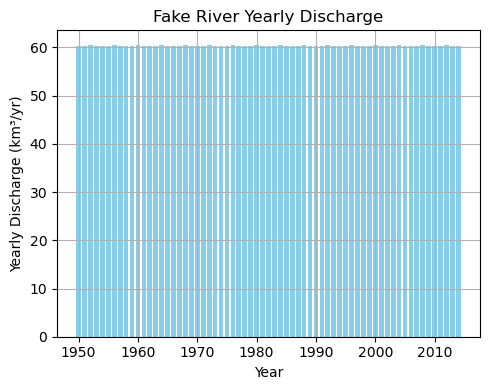

In [7]:
fake_river.plot_yearly()

In [8]:
aral_meteo = xr.open_dataset(
    "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/forcing/output/ERA5/AralSea/1940-2020/work/diagnostic/script/Derived_Makkink_evspsblpot.nc"
)

In [9]:
# Initial settings
initial_volume = 1060
ahv_file = "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/data/bathymetry/ahv_curve.csv"

# Run the model


result = aral.run_connected_aral_model(
        aral_meteo,
        rivers=[fake_river],
        ahv_csv=ahv_file,
        V0_km3=initial_volume,
        start_time="1950-01-01",
        end_time="2014-12-31",
        tqdm_position=1,
    )




Simulating Aral Sea volume balance:   0%|          | 0/23740 [00:00<?, ?it/s]

In [10]:
observation = aral.make_obs()

Found 1 NetCDF files in /home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/data/dahiti


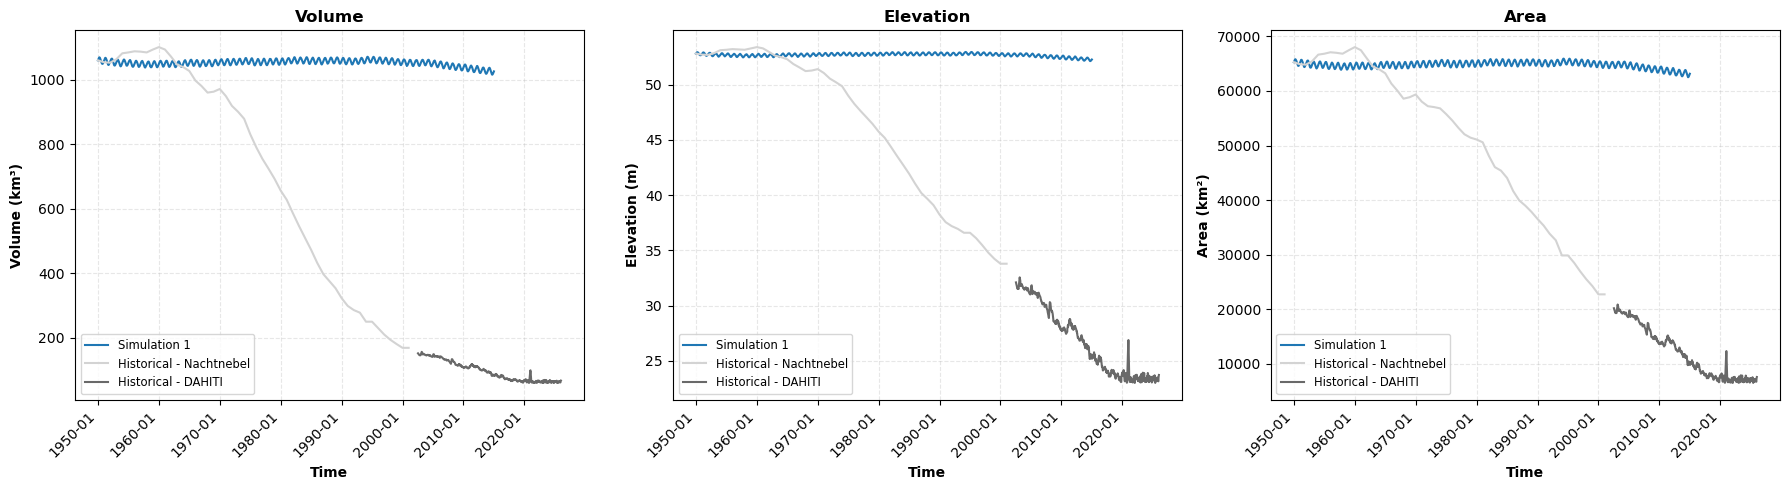

In [11]:
aral.plot_aral_results(result, observations=observation)

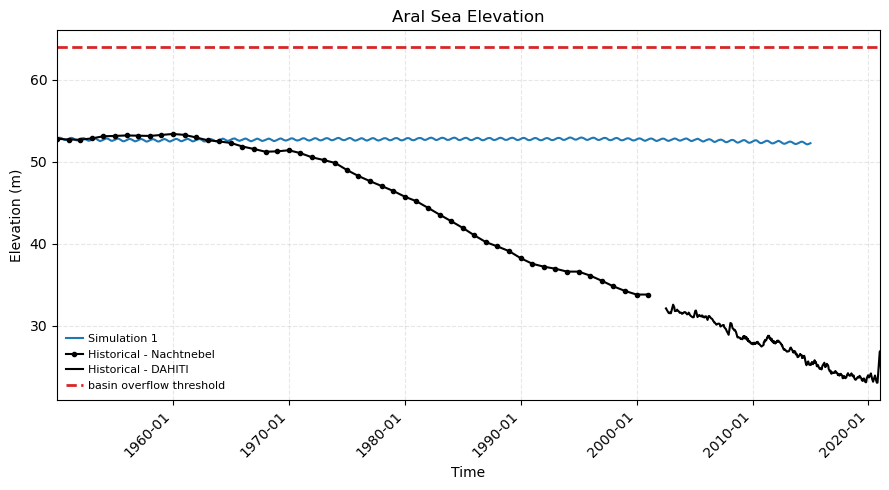

In [12]:
aral.plot_aral_elevation(result, observations=observation)

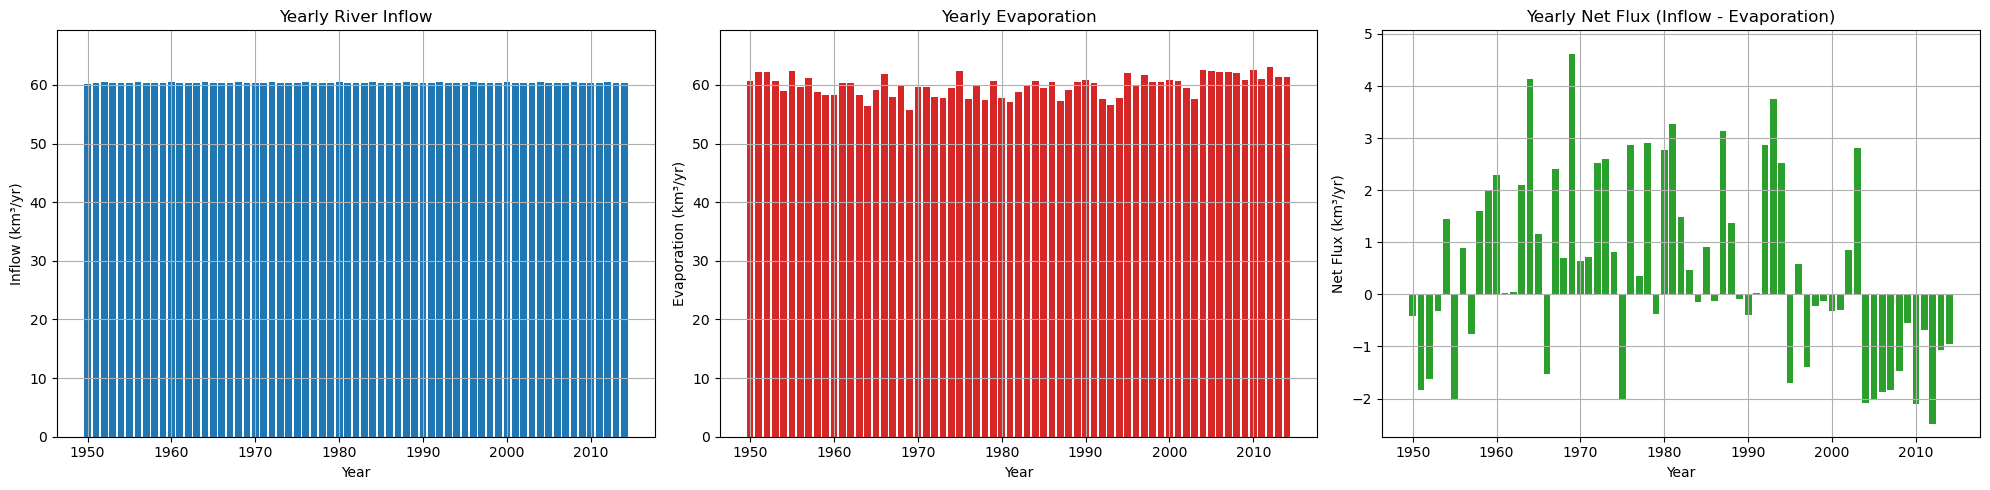

In [13]:
aral.plot_aral_fluxes(result)


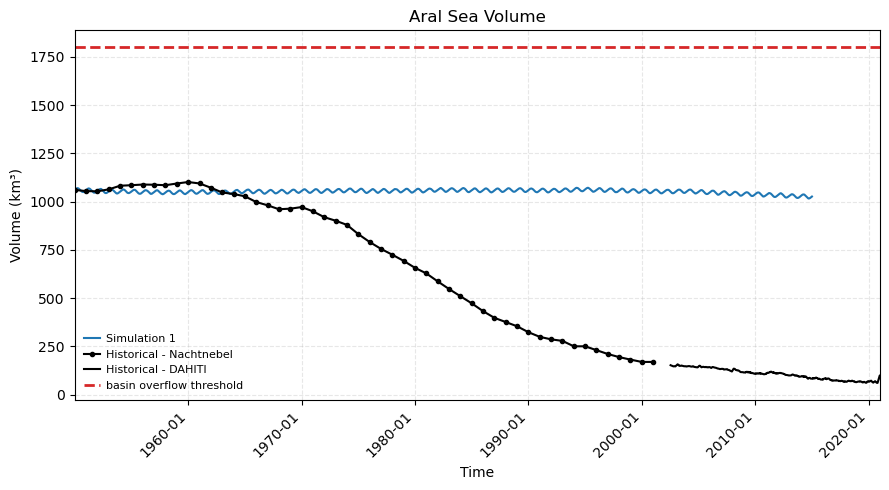

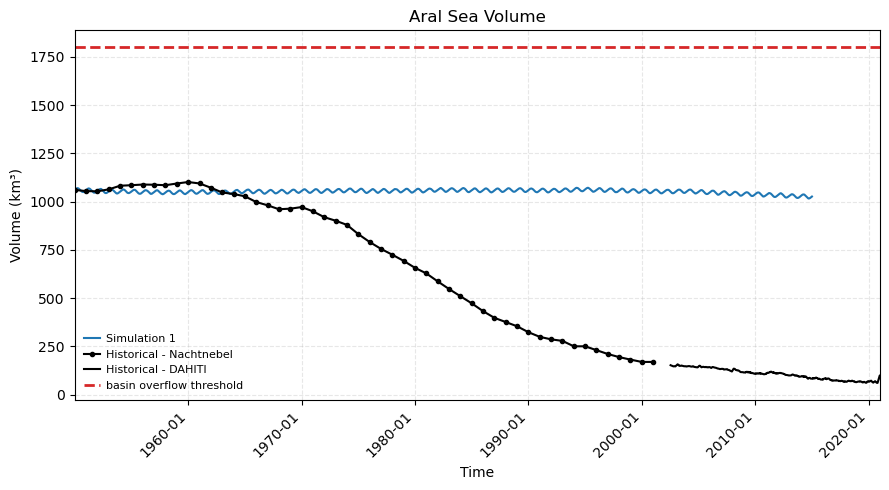

In [14]:
aral.plot_aral_volume(result, observations=observation)

In [15]:
result.columns
df = result.copy()

In [16]:
# Ensure datetime type
df["time"] = pd.to_datetime(df["time"])

# Select rows where month = 1 and day = 1
jan1 = df[(df["time"].dt.month == 1) & (df["time"].dt.day == 1)]

# Print time and elevation
print(jan1[["time", "elevation_m"]])

                     time  elevation_m
0     1950-01-01 12:00:00          NaN
365   1951-01-01 12:00:00    52.793805
730   1952-01-01 12:00:00    52.746820
1096  1953-01-01 12:00:00    52.703367
1461  1954-01-01 12:00:00    52.687144
...                   ...          ...
21915 2010-01-01 12:00:00    52.475287
22280 2011-01-01 12:00:00    52.425678
22645 2012-01-01 12:00:00    52.398869
23011 2013-01-01 12:00:00    52.343293
23376 2014-01-01 12:00:00    52.310365

[65 rows x 2 columns]


In [17]:
elevation_per_jan1 = jan1.set_index("time")["elevation_m"]
print(elevation_per_jan1)

time
1950-01-01 12:00:00          NaN
1951-01-01 12:00:00    52.793805
1952-01-01 12:00:00    52.746820
1953-01-01 12:00:00    52.703367
1954-01-01 12:00:00    52.687144
                         ...    
2010-01-01 12:00:00    52.475287
2011-01-01 12:00:00    52.425678
2012-01-01 12:00:00    52.398869
2013-01-01 12:00:00    52.343293
2014-01-01 12:00:00    52.310365
Name: elevation_m, Length: 65, dtype: float64


In [18]:
# Ensure datetime type
df["time"] = pd.to_datetime(df["time"])

# Years you want
years = [1950, 1960, 1970, 1980, 1990, 2000, 2014]

# Filter for Jan 1 of those years
selection = df[
    (df["time"].dt.month == 1) &
    (df["time"].dt.day == 31) &
    (df["time"].dt.year.isin(years))
]

# Print time and elevation
print(selection[["time", "elevation_m", "volume_km3"]])



                     time  elevation_m   volume_km3
30    1950-01-31 12:00:00    52.871032  1064.100933
3682  1960-01-31 12:00:00    52.700105  1053.060277
7335  1970-01-31 12:00:00    52.798624  1058.997147
10987 1980-01-31 12:00:00    52.819198  1060.253617
14640 1990-01-31 12:00:00    52.859235  1063.191350
18292 2000-01-31 12:00:00    52.796337  1058.851666
23406 2014-01-31 12:00:00    52.375028  1031.991111


In [19]:
def run_sim(sim_name, river):
    return aral.run_connected_aral_model(
        aral_meteo,
        rivers=[river],   # only ONE river now
        ahv_csv=ahv_file,
        V0_km3=initial_volume,
        start_time="1950-01-01",
        end_time="2014-12-31",
        tqdm_position=1,
    )

results = {
    name: run_sim(name, river)
    for name, river in fake_rivers.items()
}

Simulating Aral Sea volume balance:   0%|          | 0/23740 [00:00<?, ?it/s]

Simulating Aral Sea volume balance:   0%|          | 0/23740 [00:00<?, ?it/s]

Simulating Aral Sea volume balance:   0%|          | 0/23740 [00:00<?, ?it/s]

Simulating Aral Sea volume balance:   0%|          | 0/23740 [00:00<?, ?it/s]

Simulating Aral Sea volume balance:   0%|          | 0/23740 [00:00<?, ?it/s]

Simulating Aral Sea volume balance:   0%|          | 0/23740 [00:00<?, ?it/s]

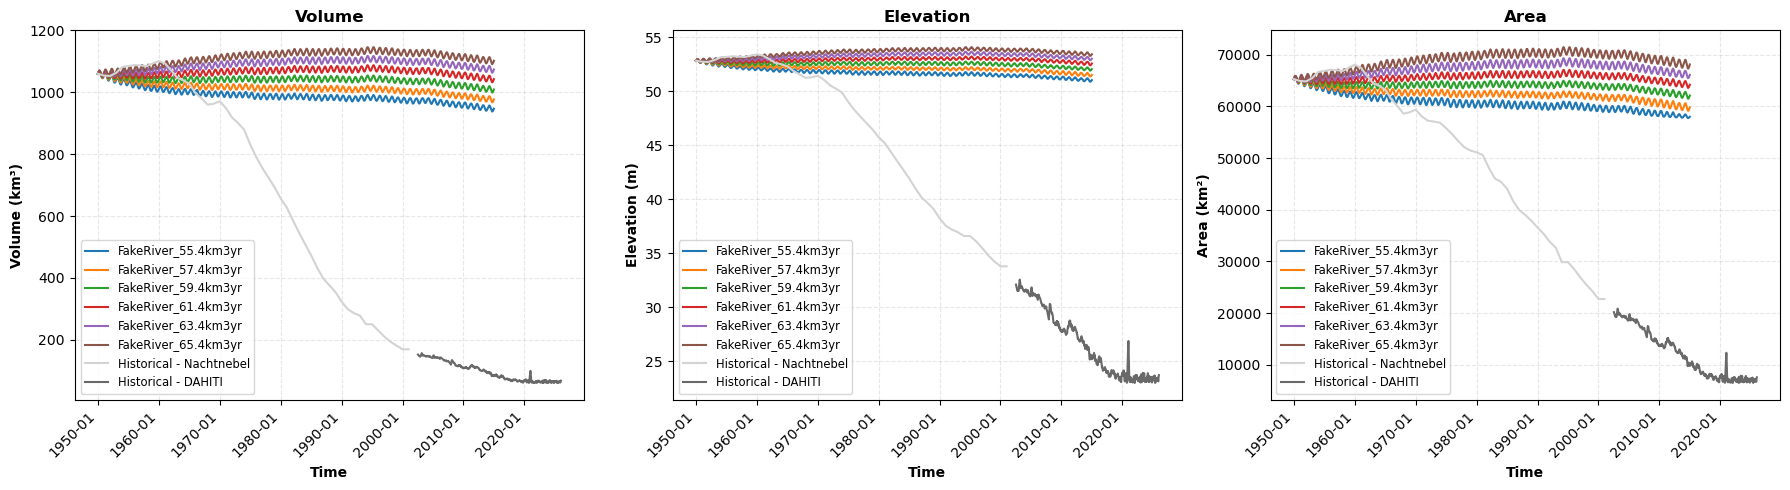

In [20]:
aral.plot_aral_results(
    list(results.values()),
    labels=list(results.keys()),
    observations=observation,
    
)

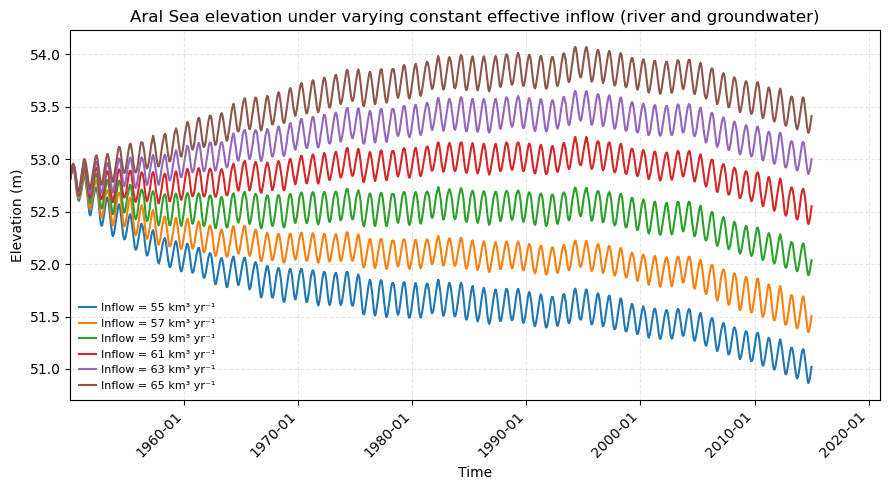

In [21]:
inflows = [55, 57, 59, 61, 63, 65]
labels = [f"Inflow = {q} km³ yr⁻¹" for q in inflows]


importlib.reload(aral)
aral.plot_aral_elevation(
    list(results.values()),
    labels=labels,
    plot_max_elevation_line=False,
    title="Aral Sea elevation under varying constant effective inflow (river and groundwater)",

)

Plot successfully saved to: aral_baseline.pdf


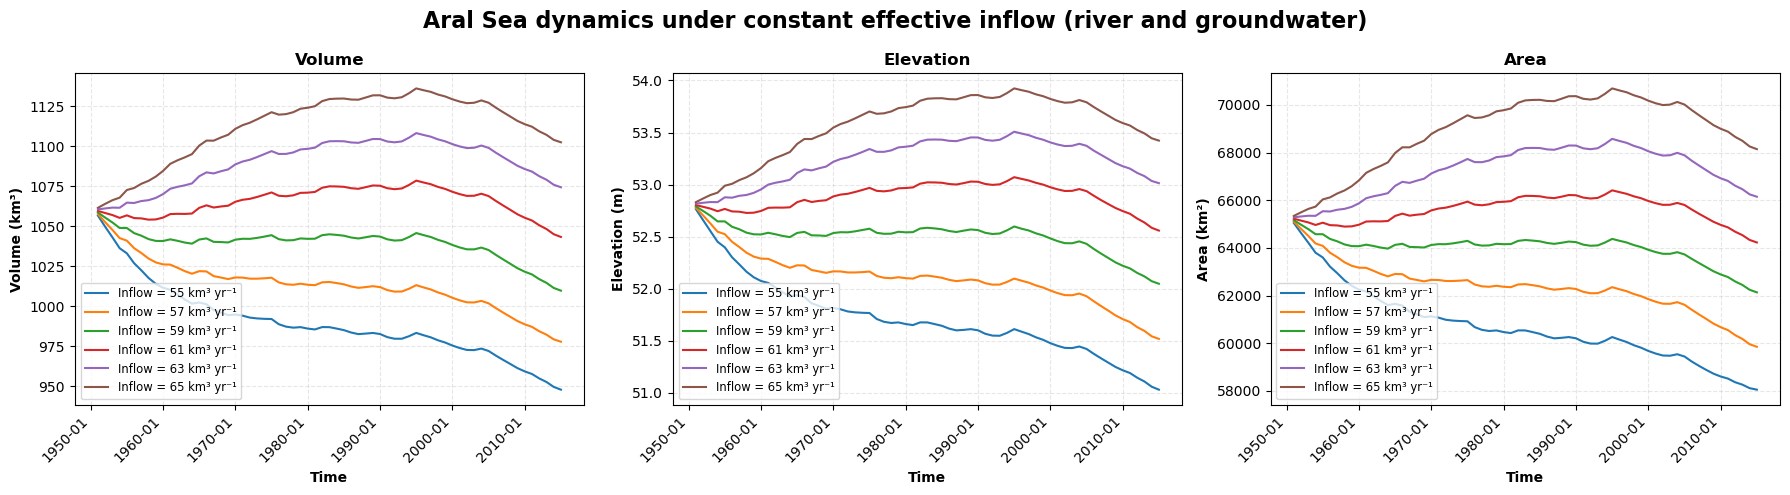

In [40]:
importlib.reload(aral)
fig = aral.plot_aral_results(
    list(results.values()),
    legend=True,
    labels=labels,
    title="Aral Sea dynamics under constant effective inflow (river and groundwater)",
    save_path = "aral_baseline.pdf",
    smooth=True,
)



In [36]:
list(results.values())
dsf = list(results.values())[0]

In [37]:
import pandas as pd

# 1. Make sure we call .values() with parentheses to get the actual data dictionary views
data_list = list(results.values())

# 2. Extract the first DataFrame from the list
dfs = data_list[0]

# 3. Now this conversion will work perfectly
dfs["time"] = pd.to_datetime(dfs["time"])

# 4. Your target years
years = [1950, 1960, 1970, 1980, 1990, 2000, 2014]

# 5. Filter for Jan 31 of those years
selection = dfs[
    (dfs["time"].dt.month == 1) &
    (dfs["time"].dt.day == 31) &
    (dfs["time"].dt.year.isin(years))
]

# 6. Print the requested data
print(selection[["time", "elevation_m", "volume_km3"]])

                     time  elevation_m   volume_km3
30    1950-01-31 12:00:00    52.865896  1063.690386
3682  1960-01-31 12:00:00    52.117399  1014.622500
7335  1970-01-31 12:00:00    51.892488   999.060444
10987 1980-01-31 12:00:00    51.711750   988.939235
14640 1990-01-31 12:00:00    51.652450   985.719941
18292 2000-01-31 12:00:00    51.529340   978.790321
23406 2014-01-31 12:00:00    51.113429   952.849989


In [38]:
import pandas as pd

# Years you want to extract
years = [1950, 1960, 1970, 1980, 1990, 2000, 2014]

# This dictionary will hold our final columns
table_data = {"Year": years}

# Loop through all DataFrames and their corresponding labels
for label, dfs in zip(labels, results.values()):
    
    # 1. Ensure datetime type
    dfs["time"] = pd.to_datetime(dfs["time"])
    
    # 2. Filter for January 31st of the target years
    selection = dfs[
        (dfs["time"].dt.month == 1) &
        (dfs["time"].dt.day == 31) &
        (dfs["time"].dt.year.isin(years))
    ]
    
    # 3. Sort by time to ensure years line up perfectly, then extract the volume column
    selection = selection.sort_values("time")
    
    # 4. Add to our table data using the scenario label as the column header
    table_data[label] = selection["volume_km3"].values

# Create the final summary DataFrame
summary_table = pd.DataFrame(table_data)

# Set 'Year' as the index for a cleaner look
summary_table.set_index("Year", inplace=True)

# Display the table
print(summary_table)

      Inflow = 55 km³ yr⁻¹  Inflow = 57 km³ yr⁻¹  Inflow = 59 km³ yr⁻¹  \
Year                                                                     
1950           1063.690386           1063.854605           1064.018824   
1960           1014.622500           1029.969214           1045.365004   
1970            999.060444           1022.754347           1046.909364   
1980            988.939235           1016.626247           1045.670445   
1990            985.719941           1015.267563           1047.132056   
2000            978.790321           1008.806209           1042.042483   
2014            952.849989            982.913566           1015.121042   

      Inflow = 61 km³ yr⁻¹  Inflow = 63 km³ yr⁻¹  Inflow = 65 km³ yr⁻¹  
Year                                                                    
1950           1064.183043           1064.347262           1064.511481  
1960           1060.764394           1076.202431           1091.445844  
1970           1071.156994           1095

In [39]:
import pandas as pd

# Years you want to extract
years = [1950, 1960, 1970, 1980, 1990, 2000, 2014]

# This dictionary will hold our final columns
elevation_table_data = {"Year": years}

# Loop through all DataFrames and their corresponding labels
for label, dfs in zip(labels, results.values()):
    
    # 1. Ensure datetime type
    dfs["time"] = pd.to_datetime(dfs["time"])
    
    # 2. Filter for January 31st of the target years
    selection = dfs[
        (dfs["time"].dt.month == 1) &
        (dfs["time"].dt.day == 31) &
        (dfs["time"].dt.year.isin(years))
    ]
    
    # 3. Sort by time to ensure years line up perfectly
    selection = selection.sort_values("time")
    
    # 4. Add to our table data using the scenario label as the column header
    elevation_table_data[label] = selection["elevation_m"].values

# Create the final summary DataFrame for elevation
elevation_table = pd.DataFrame(elevation_table_data)

# Set 'Year' as the index for a cleaner look
elevation_table.set_index("Year", inplace=True)

# Display the table
print(elevation_table)

      Inflow = 55 km³ yr⁻¹  Inflow = 57 km³ yr⁻¹  Inflow = 59 km³ yr⁻¹  \
Year                                                                     
1950             52.865896             52.867950             52.870005   
1960             52.117399             52.343238             52.600702   
1970             51.892488             52.235006             52.628486   
1980             51.711750             52.146177             52.606024   
1990             51.652450             52.126589             52.631464   
2000             51.529340             52.033431             52.541485   
2014             51.113429             51.600326             52.124174   

      Inflow = 61 km³ yr⁻¹  Inflow = 63 km³ yr⁻¹  Inflow = 65 km³ yr⁻¹  
Year                                                                    
1950             52.872059             52.874114             52.876168  
1960             52.826346             53.034885             53.256360  
1970             52.962477             53